In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/CapstoneCYBER/phishing_url_dataset_unique.csv'
df = pd.read_csv(file_path)
display(df.head())

,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


In [3]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.info())

(48812, 3)
Index(['url', 'label', 'source'], dtype='object')
                                                 url  label   source
0                  http://110.37.26.193:54956/bin.sh      1  urlhaus
1           https://sentry5.obor1shwron8.ru/4ylkytvt      1  urlhaus
2               https://d6gu.ripple-cask.ru/jid43vpd      1  urlhaus
3  http://130.12.180.34/596a96cc7bf9108cd896f33c4...      1  urlhaus
4                             https://bronze.systems      0   tranco
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48812 entries, 0 to 48811
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     48812 non-null  object
 1   label   48812 non-null  int64 
 2   source  48812 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None


In [4]:
df = df.drop(columns=['source'])

In [5]:
print(df['label'].value_counts())

label
1    24406
0    24406
Name: count, dtype: int64


In [6]:
print(df.isnull().sum())

url      0
label    0
dtype: int64


In [7]:
df['label'].unique()

array([1, 0])

# Feature Extraction

In [8]:
import numpy as np
import re
def extract_features(url):
    features = {}

    features['url_length'] = len(url)
    features['num_dots'] = url.count('.')
    features['num_slashes'] = url.count('/')
    features['num_hyphens'] = url.count('-')
    features['num_at'] = url.count('@')
    features['num_question'] = url.count('?')
    features['num_equal'] = url.count('=')
    features['num_digits'] = sum(c.isdigit() for c in url)

    # Check IP address
    features['has_ip'] = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0

    # HTTPS usage
    features['is_https'] = 1 if url.startswith('https') else 0

    # Suspicious keywords
    keywords = ['login', 'verify', 'secure', 'update', 'bank', 'account']
    features['has_suspicious'] = 1 if any(k in url.lower() for k in keywords) else 0

    # URL entropy (randomness)
    prob = [float(url.count(c)) / len(url) for c in dict.fromkeys(list(url))]
    features['entropy'] = -sum([p * np.log2(p) for p in prob])

    return features

In [9]:
features_list = df['url'].apply(extract_features)
features_df = pd.DataFrame(features_list.tolist())



In [10]:
df_new = pd.concat([features_df, df['label']], axis=1)

df_new.head()

,url_length,num_dots,num_slashes,num_hyphens,num_at,num_question,num_equal,num_digits,has_ip,is_https,has_suspicious,entropy,label
0,33,4,3,0,0,0,0,15,1,0,0,4.089552,1
1,40,2,3,0,0,0,0,4,0,1,0,4.206198,1
2,36,2,3,1,0,0,0,3,0,1,0,4.350209,1
3,91,4,4,0,0,0,0,46,1,0,0,4.357740,1
4,22,1,2,0,0,0,0,0,0,1,0,3.697846,0


In [11]:
print(df_new.columns)

Index(['url_length', 'num_dots', 'num_slashes', 'num_hyphens', 'num_at',
       'num_question', 'num_equal', 'num_digits', 'has_ip', 'is_https',
       'has_suspicious', 'entropy', 'label'],
      dtype='object')


In [12]:
import pandas as pd

corr = df_new.corr()
print(corr['label'].sort_values(ascending=False))

label             1.000000
num_dots          0.848926
num_slashes       0.777405
num_digits        0.755383
has_ip            0.743001
url_length        0.575204
entropy           0.516587
num_question      0.091131
num_equal         0.079298
num_hyphens       0.049452
num_at            0.004526
has_suspicious   -0.008810
is_https         -0.791328
Name: label, dtype: float64


# Seperate Feature and Target

In [13]:
X = df_new.drop('label', axis=1)
y = df_new['label']

In [14]:
print(X.dtypes)

url_length          int64
num_dots            int64
num_slashes         int64
num_hyphens         int64
num_at              int64
num_question        int64
num_equal           int64
num_digits          int64
has_ip              int64
is_https            int64
has_suspicious      int64
entropy           float64
dtype: object


# Encode Categorical Features

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,  # 50% of 30% = 15%
    random_state=42,
    stratify=y_temp
)

In [18]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 34168
Validation: 7322
Test: 7322


# Random Forest (Ensemble Model) → baseline

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_val_pred = rf.predict(X_val)
y_val_prob = rf.predict_proba(X_val)[:, 1]

print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("AUC:", roc_auc_score(y_val, y_val_prob))

[[3661    0]
 [   2 3659]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322

AUC: 0.9997228962253825


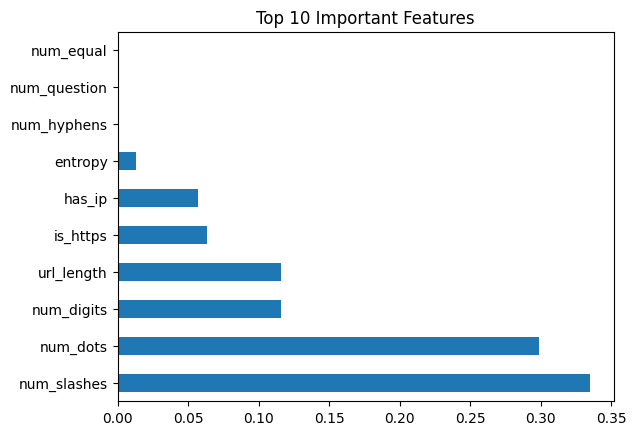

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

#XGBoost (Gradient Boosting)

In [22]:
pip install xgboost

In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_val_pred_xgb = xgb.predict(X_val)
y_val_prob_xgb = xgb.predict_proba(X_val)[:, 1]

print(confusion_matrix(y_val, y_val_pred_xgb))
print(classification_report(y_val, y_val_pred_xgb))
print("AUC:", roc_auc_score(y_val, y_val_prob_xgb))

[[3661    0]
 [   2 3659]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322

AUC: 0.999857866803811


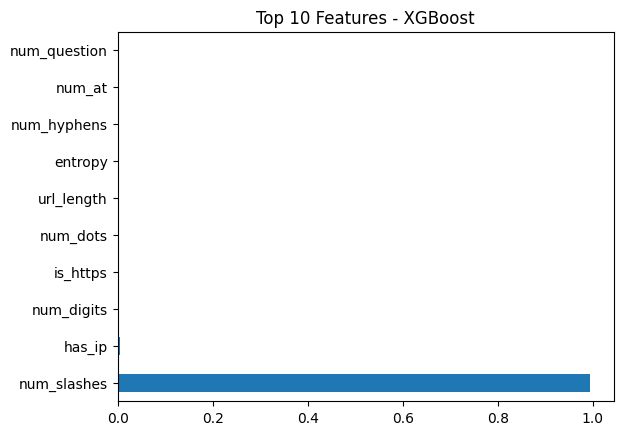

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Features - XGBoost")
plt.show()

# ANN (Neural Network)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [49]:
# Build ANN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann = Sequential()

# Input layer
ann.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))
ann.add(Dropout(0.3))

# Hidden layer
ann.add(Dense(32, activation='relu'))
ann.add(Dropout(0.2))

# Output layer
ann.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# Compile model
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
# Train Model
history = ann.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9962 - loss: 0.0249 - val_accuracy: 0.9997 - val_loss: 0.0025
Epoch 2/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9997 - val_loss: 0.0029
Epoch 3/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9998 - loss: 0.0021 - val_accuracy: 0.9997 - val_loss: 0.0027
Epoch 4/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9998 - loss: 0.0014 - val_accuracy: 0.9997 - val_loss: 0.0029
Epoch 5/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9997 - val_loss: 0.0029
Epoch 6/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0029
Epoch 7/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0030
Epoch 8/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9999 - loss: 0.0014 - 

In [30]:
# Evaluate ANN
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_val_pred_ann = (ann.predict(X_val_scaled) > 0.5).astype(int)
y_val_prob_ann = ann.predict(X_val_scaled)

print(confusion_matrix(y_val, y_val_pred_ann))
print(classification_report(y_val, y_val_pred_ann))
print("AUC:", roc_auc_score(y_val, y_val_prob_ann))

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[3661    0]
 [   2 3659]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322

AUC: 0.9998499207747327


In [31]:
import numpy as np

print(np.intersect1d(X_train[:,0], X_val[:,0]))

[-1.14851025e+00 -1.07707056e+00 -1.00563087e+00 -9.34191177e-01
 -8.62751487e-01 -7.91311797e-01 -7.19872107e-01 -6.48432417e-01
 -5.76992727e-01 -5.05553038e-01 -4.34113348e-01 -3.62673658e-01
 -2.91233968e-01 -2.19794278e-01 -1.48354588e-01 -7.69148984e-02
 -5.47520855e-03  6.59644813e-02  1.37404171e-01  2.08843861e-01
  2.80283551e-01  3.51723241e-01  4.23162931e-01  4.94602620e-01
  5.66042310e-01  6.37482000e-01  7.08921690e-01  7.80361380e-01
  8.51801070e-01  9.23240760e-01  9.94680450e-01  1.06612014e+00
  1.13755983e+00  1.20899952e+00  1.28043921e+00  1.35187890e+00
  1.42331859e+00  1.49475828e+00  1.56619797e+00  1.63763766e+00
  1.70907735e+00  1.78051704e+00  1.85195673e+00  1.92339642e+00
  1.99483611e+00  2.06627580e+00  2.13771549e+00  2.20915518e+00
  2.28059487e+00  2.35203456e+00  2.42347425e+00  2.49491394e+00
  2.56635363e+00  2.63779332e+00  2.78067270e+00  2.85211239e+00
  2.92355208e+00  2.99499177e+00  3.06643146e+00  3.13787115e+00
  3.20931084e+00  3.28075

# HYPERPARAMETER TUNING

RANDOM FOREST — Grid Search

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Get best tuned model
best_rf = grid_rf.best_estimator_

# Predictions
y_val_pred_rf = best_rf.predict(X_val)
y_val_prob_rf = best_rf.predict_proba(X_val)[:, 1]

# =========================
# Print metrics
# =========================
print("===== TUNED RANDOM FOREST RESULTS =====\n")

print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf))
print("Recall:", recall_score(y_val, y_val_pred_rf))
print("F1 Score:", f1_score(y_val, y_val_pred_rf))
print("AUC:", roc_auc_score(y_val, y_val_prob_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_rf))

===== TUNED RANDOM FOREST RESULTS =====

Accuracy: 0.9997268505872713
Precision: 1.0
Recall: 0.9994537011745425
F1 Score: 0.9997267759562841
AUC: 0.9997228962253825

Confusion Matrix:
 [[3661    0]
 [   2 3659]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322



XGBOOST — Random Search

In [35]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_xgb.fit(X_train, y_train)

print("Best XGB Params:", random_xgb.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best XGB Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Get best tuned model
best_xgb = random_xgb.best_estimator_

# Predictions
y_val_pred_xgb = best_xgb.predict(X_val)
y_val_prob_xgb = best_xgb.predict_proba(X_val)[:, 1]

# =========================
# Print metrics
# =========================
print("===== TUNED XGBOOST RESULTS =====\n")

print("Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print("Precision:", precision_score(y_val, y_val_pred_xgb))
print("Recall:", recall_score(y_val, y_val_pred_xgb))
print("F1 Score:", f1_score(y_val, y_val_pred_xgb))
print("AUC:", roc_auc_score(y_val, y_val_prob_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_xgb))

===== TUNED XGBOOST RESULTS =====

Accuracy: 0.9997268505872713
Precision: 1.0
Recall: 0.9994537011745425
F1 Score: 0.9997267759562841
AUC: 0.9998054901614356

Confusion Matrix:
 [[3661    0]
 [   2 3659]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322



ANN — Manual Hyperparameter Tuning

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_ann(units1=64, units2=32, dropout1=0.3, dropout2=0.2):
    model = Sequential()

    model.add(Dense(units1, activation='relu', input_dim=X_train_scaled.shape[1]))
    model.add(Dropout(dropout1))

    model.add(Dense(units2, activation='relu'))
    model.add(Dropout(dropout2))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [38]:
# Model 1
ann1 = build_ann(64, 32, 0.3, 0.2)
ann1.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=10, batch_size=32)

# Model 2 (tuned)
# ann2 = build_ann(128, 64, 0.4, 0.3)
# ann2.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=10, batch_size=32)

# Model 3 (smaller)
# ann3 = build_ann(32, 16, 0.2, 0.1)
# ann3.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9916 - loss: 0.0324 - val_accuracy: 0.9997 - val_loss: 0.0026
Epoch 2/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.9997 - val_loss: 0.0027
Epoch 3/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9998 - loss: 0.0019 - val_accuracy: 0.9997 - val_loss: 0.0025
Epoch 4/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 0.9997 - val_loss: 0.0027
Epoch 5/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.9997 - val_loss: 0.0032
Epoch 6/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 0.9997 - val_loss: 0.0030
Epoch 7/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0028
Epoch 8/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accurac

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np

# Predictions
y_val_pred_ann = (ann1.predict(X_val_scaled) > 0.5).astype(int)
y_val_prob_ann = ann1.predict(X_val_scaled)

# =========================
# Print metrics
# =========================
print("===== ANN RESULTS =====\n")

print("Accuracy:", accuracy_score(y_val, y_val_pred_ann))
print("Precision:", precision_score(y_val, y_val_pred_ann))
print("Recall:", recall_score(y_val, y_val_pred_ann))
print("F1 Score:", f1_score(y_val, y_val_pred_ann))
print("AUC:", roc_auc_score(y_val, y_val_prob_ann))

print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_ann))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_ann))

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
===== ANN RESULTS =====

Accuracy: 0.9997268505872713
Precision: 1.0
Recall: 0.9994537011745425
F1 Score: 0.9997267759562841
AUC: 0.9998476824566824

Confusion Matrix:
 [[3661    0]
 [   2 3659]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322



# KFold Cross Validation

👉 K-Fold Cross Validation is a method to test how well your model performs on different parts of the data.

Random Forest (Tuned)

In [40]:
from sklearn.model_selection import cross_val_score

best_rf = grid_rf.best_estimator_

rf_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Random Forest F1 Scores:", rf_scores)
print("Average F1:", rf_scores.mean())

Random Forest F1 Scores: [0.99985365 1.         1.         0.99970726 0.99985361]
Average F1: 0.9998829039800103


XGBoost (Tuned)

In [41]:
best_xgb = random_xgb.best_estimator_

xgb_scores = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("\nXGBoost F1 Scores:", xgb_scores)
print("Average F1:", xgb_scores.mean())


XGBoost F1 Scores: [0.99985365 1.         1.         0.99970726 0.99985361]
Average F1: 0.9998829039800103


ANN (SPECIAL CASE)

In [42]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ann_scores = []

for train_index, val_index in kf.split(X_train_scaled):
    X_tr, X_va = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_va = y_train.iloc[train_index], y_train.iloc[val_index]

    model = build_ann(64, 32, 0.3, 0.2)
    model.fit(X_tr, y_tr, epochs=5, batch_size=32, verbose=0)

    pred = (model.predict(X_va) > 0.5).astype(int)
    score = f1_score(y_va, pred)

    ann_scores.append(score)

print("\nANN F1 Scores:", ann_scores)
print("Average F1:", np.mean(ann_scores))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

ANN F1 Scores: [0.9998539079620161, 0.9998553450021698, 1.0, 0.9997096399535423, 0.9997017596182524]
Average F1: 0.9998241305071961


In [43]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================
# TRAIN BASELINE MODELS (BEFORE TUNING)
# =========================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# =========================
# BEFORE TUNING (Baseline Models)
# =========================
rf_pred_before = rf.predict(X_val)
xgb_pred_before = xgb.predict(X_val)
ann_pred_before = (ann.predict(X_val_scaled) > 0.5).astype(int)

# =========================
# AFTER TUNING (Best Models)
# =========================
best_rf = grid_rf.best_estimator_
best_xgb = random_xgb.best_estimator_

rf_pred_after = best_rf.predict(X_val)
xgb_pred_after = best_xgb.predict(X_val)
ann_pred_after = (ann.predict(X_val_scaled) > 0.5).astype(int)  # same ANN

# =========================
# CREATE COMPARISON TABLE
# =========================
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'ANN'],

    'Accuracy Before': [
        accuracy_score(y_val, rf_pred_before),
        accuracy_score(y_val, xgb_pred_before),
        accuracy_score(y_val, ann_pred_before)
    ],

    'Accuracy After': [
        accuracy_score(y_val, rf_pred_after),
        accuracy_score(y_val, xgb_pred_after),
        accuracy_score(y_val, ann_pred_after)
    ],

    'Precision Before': [
        precision_score(y_val, rf_pred_before),
        precision_score(y_val, xgb_pred_before),
        precision_score(y_val, ann_pred_before)
    ],

    'Precision After': [
        precision_score(y_val, rf_pred_after),
        precision_score(y_val, xgb_pred_after),
        precision_score(y_val, ann_pred_after)
    ],

    'Recall Before': [
        recall_score(y_val, rf_pred_before),
        recall_score(y_val, xgb_pred_before),
        recall_score(y_val, ann_pred_before)
    ],

    'Recall After': [
        recall_score(y_val, rf_pred_after),
        recall_score(y_val, xgb_pred_after),
        recall_score(y_val, ann_pred_after)
    ],

    'F1 Before': [
        f1_score(y_val, rf_pred_before),
        f1_score(y_val, xgb_pred_before),
        f1_score(y_val, ann_pred_before)
    ],

    'F1 After': [
        f1_score(y_val, rf_pred_after),
        f1_score(y_val, xgb_pred_after),
        f1_score(y_val, ann_pred_after)
    ]
})

# Round values
comparison = comparison.round(4)

print("===== MODEL COMPARISON: BEFORE vs AFTER TUNING =====\n")
print(comparison)

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
===== MODEL COMPARISON: BEFORE vs AFTER TUNING =====

           Model  Accuracy Before  Accuracy After  Precision Before  \
0  Random Forest           0.9997          0.9997               1.0   
1        XGBoost           0.9997          0.9997               1.0   
2            ANN           0.9997          0.9997               1.0   

   Precision After  Recall Before  Recall After  F1 Before  F1 After  
0              1.0         0.9995        0.9995     0.9997    0.9997  
1              1.0         0.9995        0.9995     0.9997    0.9997  
2              1.0         0.9995        0.9995     0.9997    0.9997  


Although all models achieved similar performance, XGBoost is selected as the best model due to its superior capability in handling complex patterns through boosting. It sequentially improves weak learners, making it more robust compared to Random Forest and more efficient than ANN in terms of training time and scalability.

Additionally, XGBoost provides better control over overfitting through regularization parameters and is widely used in real-world classification problems due to its reliability and performance. Therefore, considering both performance and practical applicability, XGBoost is chosen as the final model for phishing URL detection.

# FINAL TEST SET EVALUATION

In [45]:
best_model = random_xgb.best_estimator_

y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("===== FINAL TEST RESULTS =====\n")
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print("AUC:", roc_auc_score(y_test, y_test_prob))

===== FINAL TEST RESULTS =====

[[3661    0]
 [   2 3659]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322

AUC: 0.9998026176532713


# ROC CURVE

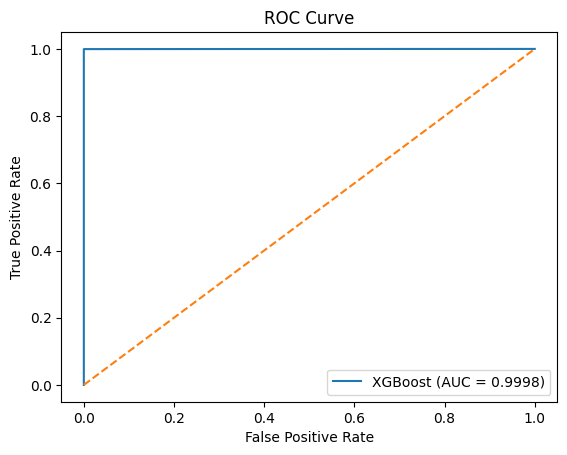

In [46]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Using best model (XGBoost)
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label='XGBoost (AUC = {:.4f})'.format(roc_auc_score(y_test, y_test_prob)))
plt.plot([0, 1], [0, 1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve shows that the model achieves a near-perfect classification performance, as the curve is very close to the top-left corner of the graph. This indicates that the model has a very high true positive rate while maintaining a very low false positive rate.

The AUC value of 0.9998 further confirms that the model is highly effective in distinguishing between phishing and legitimate URLs. This means the model can almost perfectly classify URLs with minimal errors.

# CONFUSION MATRIX HEATMAP

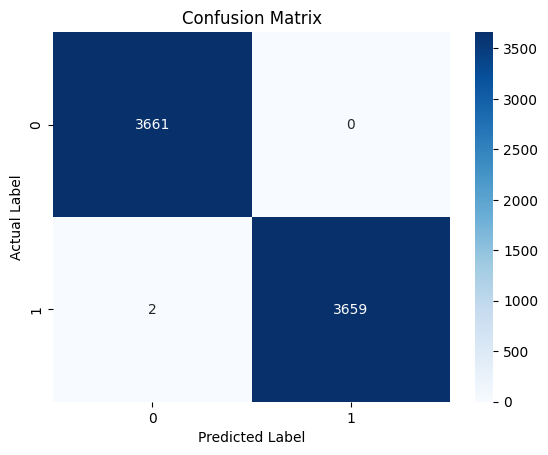

In [47]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

# FEATURE IMPORTANCE

Feature importance shows how much each feature contributes to the model’s decision-making process. Higher values indicate that the feature has a stronger influence on predicting whether a URL is phishing or legitimate.

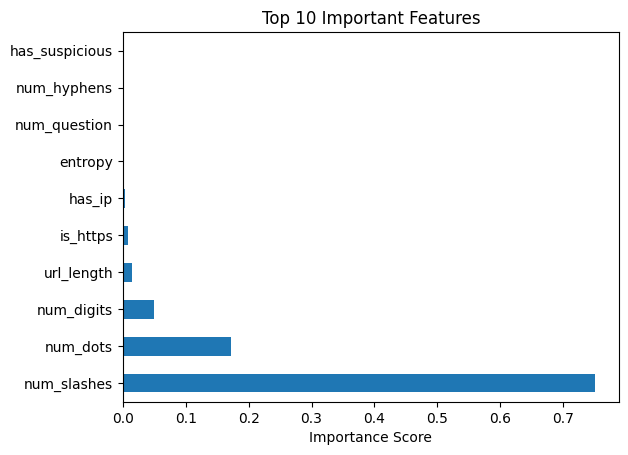

In [48]:
import pandas as pd

importance = pd.Series(best_model.feature_importances_, index=X.columns)

plt.figure()
importance.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()